# 1. Import Libraries

This notebook uses Python libraries for data manipulation, visualization, machine learning, and causal inference.

The imported packages provide functionality for loading data, performing exploratory data analysis (EDA), preprocessing, model development, and result visualization.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from setup import configure_notebook

configure_notebook()

print("Notebook configured successfully.")

Notebook configured successfully.


# 2. Load Configuration

Project-specific configurations, such as the dataset location and key variable names, are stored in a separate `.env` file.

Separating configuration from source code improves portability and makes it easier to reuse this notebook with different datasets.

In [28]:
from features.configure import load_configuration

config = load_configuration()

DATASET_PATH = config["dataset_path"]
TARGET = config["target"]
TREATMENT = config["treatment"]

print("Configuration Loaded")
print(f"Dataset Path     : {DATASET_PATH}")
print(f"Target Column    : {TARGET}")
print(f"Treatment Column : {TREATMENT}")

Configuration Loaded
Dataset Path     : /Users/baotram/Desktop/Criteo Uplift/Data/criteo-uplift-v2.1.csv
Target Column    : conversion
Treatment Column : treatment


# 3. Load Dataset

The dataset is loaded from the local machine using the file path specified in the configuration file.

After loading, the dataset is stored as a Pandas DataFrame, which will be used throughout the remainder of the analysis.

In [29]:
df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


# 4. Dataset Overview

Before performing any analysis, it is important to understand the overall structure of the dataset.

This section provides a high-level overview, including the dataset dimensions, variable types, summary statistics, and the identification of treatment, outcome, and feature variables.

## 4.1 Dataset Shape

This subsection reports the number of observations (rows) and variables (columns) in the dataset.

Understanding the dataset size provides an initial impression of the available information and the scale of the analysis.

In [30]:
rows, cols = df.shape

print(f"Rows    : {rows:,}")
print(f"Columns : {cols}")

Rows    : 13,979,592
Columns : 16


## 4.2 Preview of the Dataset

The first few observations are displayed to verify that the dataset has been loaded correctly.

This quick inspection also helps identify the structure of the variables and detect any obvious formatting issues.

In [31]:
df.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.62,10.06,8.98,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0
1,12.62,10.06,9.00,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0
2,12.62,10.06,8.96,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0
3,12.62,10.06,9.00,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0
4,12.62,10.06,9.04,4.68,10.28,4.12,0.29,4.83,3.96,13.19,5.30,-0.17,1,0,0,0


## 4.3 Dataset Information

This subsection summarizes the data types, number of non-null observations, and memory usage of the dataset.

The information is useful for identifying variable types and detecting potential missing values.

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13979592 entries, 0 to 13979591
Data columns (total 16 columns):
 #   Column      Dtype  
---  ------      -----  
 0   f0          float64
 1   f1          float64
 2   f2          float64
 3   f3          float64
 4   f4          float64
 5   f5          float64
 6   f6          float64
 7   f7          float64
 8   f8          float64
 9   f9          float64
 10  f10         float64
 11  f11         float64
 12  treatment   int64  
 13  conversion  int64  
 14  visit       int64  
 15  exposure    int64  
dtypes: float64(12), int64(4)
memory usage: 1.7 GB


## 4.4 Summary Statistics

Descriptive statistics are generated to summarize the numerical and categorical variables.

The summary provides information such as central tendency, variability, minimum and maximum values, and category frequencies, which are useful for identifying unusual patterns before further analysis.

In [33]:
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
f0,13979592.00,19.62,5.38,12.62,12.62,21.92,24.44,26.75
f1,13979592.00,10.07,0.10,10.06,10.06,10.06,10.06,16.34
f2,13979592.00,8.45,0.30,8.21,8.21,8.21,8.72,9.05
f3,13979592.00,4.18,1.34,-8.40,4.68,4.68,4.68,4.68
f4,13979592.00,10.34,0.34,10.28,10.28,10.28,10.28,21.12
f5,13979592.00,4.03,0.43,-9.01,4.12,4.12,4.12,4.12
f6,13979592.00,-4.16,4.58,-31.43,-6.70,-2.41,0.29,0.29
f7,13979592.00,5.10,1.21,4.83,4.83,4.83,4.83,12.00
f8,13979592.00,3.93,0.06,3.64,3.91,3.97,3.97,3.97
f9,13979592.00,16.03,7.02,13.19,13.19,13.19,13.19,75.30


## 4.5 Column Names

This subsection lists all variables contained in the dataset.

Reviewing the column names helps verify that the dataset matches the expected schema and simplifies feature selection in later stages.

In [34]:
print("Columns:")

for col in df.columns:
    print(f"- {col}")

Columns:
- f0
- f1
- f2
- f3
- f4
- f5
- f6
- f7
- f8
- f9
- f10
- f11
- treatment
- conversion
- visit
- exposure


## 4.6 Data Types

Each variable is classified according to its data type.

Correct data types are essential for selecting appropriate preprocessing techniques and statistical analyses.

In [35]:
dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str)
})

dtype_df

,Column,Data Type
f0,f0,float64
f1,f1,float64
f2,f2,float64
f3,f3,float64
f4,f4,float64
f5,f5,float64
f6,f6,float64
f7,f7,float64
f8,f8,float64
f9,f9,float64


## 4.7 Variable Roles

Variables are categorized according to their role within the causal inference framework.

Specifically, the treatment variable, outcome variable, and predictor variables are identified before model development.

In [36]:
features = [
    col
    for col in df.columns
    if col not in [TARGET, TREATMENT]
]

print(f"Treatment Variable : {TREATMENT}")
print(f"Outcome Variable   : {TARGET}")
print(f"Number of Features : {len(features)}")

Treatment Variable : treatment
Outcome Variable   : conversion
Number of Features : 14


## 4.8 Feature List

This subsection presents the list of predictor variables that will be used during exploratory analysis and model training.

Treatment and outcome variables are excluded from this list.

In [37]:
feature_df = pd.DataFrame({
    "Feature": features
})

feature_df

,Feature
0,f0
1,f1
2,f2
3,f3
4,f4
5,f5
6,f6
7,f7
8,f8
9,f9


## 4.9 Outcome Distribution

The distribution of the outcome variable is examined to understand the balance between positive and negative outcomes.

This information is useful for identifying potential class imbalance that may influence model performance.

In [38]:
df[TARGET].value_counts(dropna=False)

conversion
0    13938818
1       40774
Name: count, dtype: int64

## 4.10 Treatment Distribution

The distribution of the treatment assignment is examined to understand how observations are allocated between the treatment and control groups.

Balanced treatment allocation generally provides a stronger foundation for estimating treatment effects.

In [39]:
df[TREATMENT].value_counts(dropna=False)

treatment
1    11882655
0     2096937
Name: count, dtype: int64

# 5. Data Quality Assessment

High-quality data is essential for reliable causal inference and machine learning.

This section evaluates the completeness, consistency, and validity of the dataset by examining missing values, duplicate observations, invalid values, and potential outliers.

## 5.1 Missing Values

This subsection evaluates the completeness of the dataset by identifying missing values across all variables.

Features with substantial missing values may require imputation or additional preprocessing before model training.

In [40]:
missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_df = missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_df

,Missing Count,Missing Percentage
f0,0,0.00
f1,0,0.00
f2,0,0.00
f3,0,0.00
f4,0,0.00
f5,0,0.00
f6,0,0.00
f7,0,0.00
f8,0,0.00
f9,0,0.00


## 5.2 Duplicate Rows

Duplicate observations are identified to determine whether the dataset contains repeated records.

Duplicate rows may introduce bias and unnecessarily increase the influence of certain observations during model training.

In [41]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_count}")

# No duplicate rows were removed at this stage.

Duplicate Rows : 1259545


## 5.3 Invalid Values

This section checks whether the dataset contains values that violate business rules or expected data formats.

Examples include:

- Negative ages
- Negative income
- Invalid treatment labels
- Invalid outcome labels
- Unexpected categorical values

Any invalid values identified in this step will be addressed during data preprocessing.

In [42]:
# Check treatment values
df[TREATMENT].value_counts(dropna=False)

# Check outcome values
df[TARGET].value_counts(dropna=False)

conversion
0    13938818
1       40774
Name: count, dtype: int64

## 5.4 Outliers

This section identifies potential outliers in numerical features using boxplots and the Interquartile Range (IQR) method.

The objective is to understand the distribution of numeric variables and determine whether extreme values require further investigation or treatment before modeling.

In [43]:
numeric_cols = df.loc[:, "f0":"f11"].columns

outlier_summary = []

for col in numeric_cols:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (df[col] < lower_bound)
        | (df[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": outlier_count,
        "Percentage": round(outlier_count / len(df) * 100, 2)
    })

outlier_df = (
    pd.DataFrame(outlier_summary)
      .sort_values("Percentage", ascending=False)
)

display(outlier_df)

,Feature,Outlier Count,Percentage
9,f9,2866257,20.50
3,f3,2535597,18.14
8,f8,920642,6.59
5,f5,741443,5.30
7,f7,741443,5.30
4,f4,606897,4.34
10,f10,606897,4.34
11,f11,202386,1.45
6,f6,178726,1.28
1,f1,171950,1.23


# 6. Exploratory Data Analysis

This section explores the underlying characteristics of the dataset beyond data quality.

The objective is to understand the distribution of features, relationships between variables, treatment allocation, and outcome behaviour before model development.

The findings from this section will guide preprocessing decisions and support the selection of appropriate causal inference models.

## 6.1 Treatment Assignment Distribution

Examine the distribution of treatment and control groups to assess treatment assignment balance. A balanced distribution helps ensure sufficient observations in each group for reliable causal effect estimation and supports the validity of subsequent causal inference analyses.

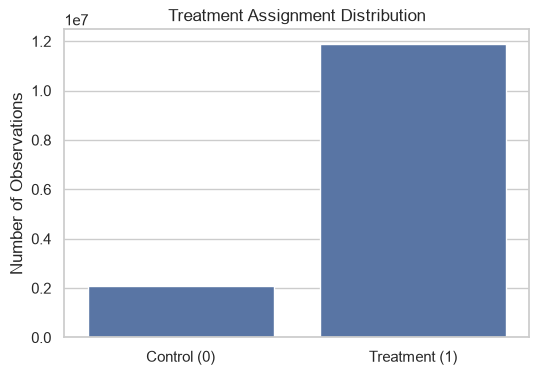

treatment
0   15.00
1   85.00
Name: count, dtype: float64

In [44]:
treatment_counts = (
    df[TREATMENT]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6,4))

sns.barplot(
    x=["Control (0)", "Treatment (1)"],
    y=treatment_counts.values
)

plt.title("Treatment Assignment Distribution")
plt.ylabel("Number of Observations")

plt.show()

display(
    (
        treatment_counts / len(df) * 100
    ).round(2)
)

## Findings

The treatment assignment is substantially imbalanced.

Approximately **85.0%** of observations belong to the treatment group, while only **15.0%** belong to the control group.

## Implication

The unequal treatment allocation suggests that the dataset is not derived from a balanced randomized experiment. This imbalance should be considered when selecting causal inference methods, as some uplift learners are specifically designed to handle unequal treatment groups.

## Decision

Treatment imbalance will be taken into account during model selection and interpretation of treatment effects.

## 6.2 Outcome Distribution

Examine the distribution of the outcome variable to understand the proportion of converted and non-converted customers. This helps assess class imbalance, establish the baseline conversion rate, and provide context for evaluating treatment effects in subsequent causal analyses.

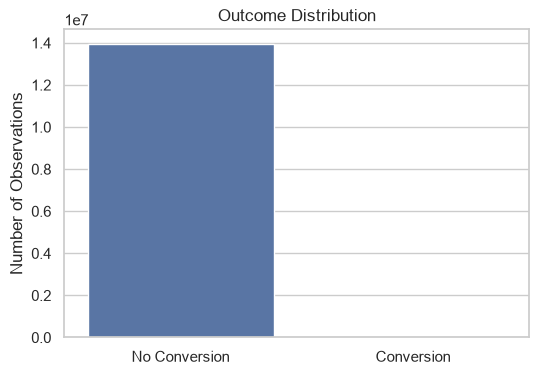

conversion
0   99.71
1    0.29
Name: count, dtype: float64

In [45]:
conversion_counts = (
    df[TARGET]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6,4))

sns.barplot(
    x=["No Conversion", "Conversion"],
    y=conversion_counts.values
)

plt.title("Outcome Distribution")
plt.ylabel("Number of Observations")

plt.show()

display(
    (
        conversion_counts / len(df) * 100
    ).round(4)
)

## Findings

The outcome variable is highly imbalanced.

Approximately **99.71%** of observations did not convert, while only **0.29%** resulted in a conversion.

## Implication

The extremely low conversion rate indicates that successful conversions are rare events. As a result, overall prediction accuracy alone would not be an appropriate evaluation metric. In the context of causal inference, the rarity of positive outcomes may also increase the variance of treatment effect estimates.

## Decision

The severe class imbalance will be considered when interpreting model performance and estimating treatment effects.

## 6.3 Conversion Rate by Treatment

Compare the conversion rates between the treatment and control groups to obtain an initial indication of treatment effectiveness. This comparison provides a preliminary assessment before applying causal inference methods to estimate unbiased treatment effects.

treatment
0   0.19
1   0.31
Name: conversion, dtype: float64

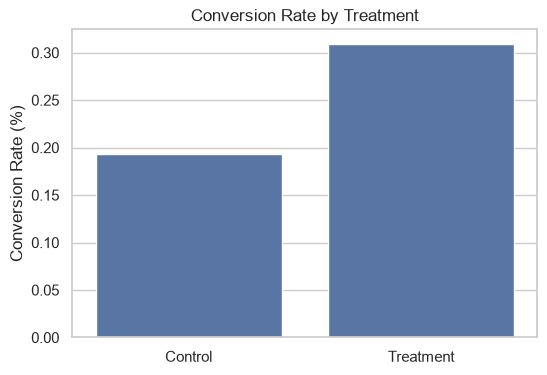

In [46]:
conversion_rate = (
    df
    .groupby(TREATMENT)[TARGET]
    .mean()
    * 100
)

display(conversion_rate)

plt.figure(figsize=(6,4))

sns.barplot(
    x=["Control", "Treatment"],
    y=conversion_rate.values
)

plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Treatment")

plt.show()

## Findings

The treatment group achieved a higher conversion rate than the control group.

- **Control Group:** 0.19%
- **Treatment Group:** 0.31%

This represents an absolute increase of approximately **0.12 percentage points** after treatment exposure.

## Implication

The higher conversion rate observed in the treatment group suggests that the treatment has a positive overall effect on conversion. However, this comparison reflects an observed association rather than a causal effect, as differences in customer characteristics may still exist between the treatment and control groups.

## Decision

The next step is to apply causal inference methods to estimate treatment effects while accounting for potential confounding. More advanced models will then be used to estimate heterogeneous treatment effects across individual customers.

## 6.4 Correlation Matrix

Examine the pairwise correlations among numerical features to identify potential multicollinearity and relationships between variables. Understanding feature correlations supports feature interpretation and informs subsequent causal inference and uplift modeling.

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11
f0,1.00,-0.09,-0.51,0.28,-0.09,0.05,-0.27,-0.00,0.40,-0.29,-0.09,0.08
f1,-0.09,1.00,-0.01,-0.33,0.15,-0.57,-0.19,0.15,-0.14,0.17,0.07,-0.15
f2,-0.51,-0.01,1.00,0.01,0.02,-0.02,0.18,0.04,-0.37,-0.05,0.09,0.03
f3,0.28,-0.33,0.01,1.00,-0.20,0.33,0.55,-0.20,0.28,-0.30,-0.14,0.17
f4,-0.09,0.15,0.02,-0.20,1.00,-0.20,-0.16,0.11,-0.41,0.36,0.66,-0.68
f5,0.05,-0.57,-0.02,0.33,-0.20,1.00,0.36,-0.75,0.20,-0.16,-0.13,0.12
f6,-0.27,-0.19,0.18,0.55,-0.16,0.36,1.00,-0.32,0.12,-0.11,-0.12,0.09
f7,-0.00,0.15,0.04,-0.20,0.11,-0.75,-0.32,1.00,-0.14,0.09,0.10,-0.05
f8,0.40,-0.14,-0.37,0.28,-0.41,0.20,0.12,-0.14,1.00,-0.75,-0.40,0.25
f9,-0.29,0.17,-0.05,-0.30,0.36,-0.16,-0.11,0.09,-0.75,1.00,0.27,-0.36


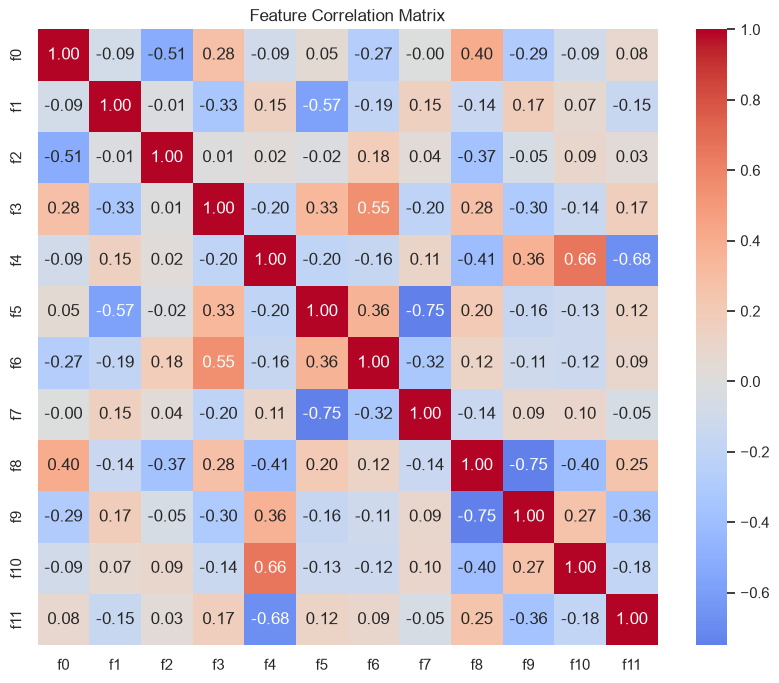

In [47]:
corr = df[
    [f"f{i}" for i in range(12)]
].corr()

display(corr)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,      # Hiển thị hệ số tương quan
    fmt=".2f"        # Làm tròn 2 chữ số
)

plt.title("Feature Correlation Matrix")

plt.show()

## 6.5 Top Correlated Feature Pairs

Identify the feature pairs with the strongest correlations to detect potential multicollinearity and reveal important relationships among predictors. This analysis supports feature interpretation and provides additional insight before causal inference and uplift modeling.

In [48]:
corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .sort_values(key=lambda x: x.abs(), ascending=False)
        .rename("Correlation")
        .to_frame()
)

display(corr_pairs.head(20))

Correlation
f8  f9         -0.75
f9  f8         -0.75
f7  f5         -0.75
f5  f7         -0.75
f11 f4         -0.68
f4  f11        -0.68
    f10         0.66
f10 f4          0.66
f1  f5         -0.57
f5  f1         -0.57
f6  f3          0.55
f3  f6          0.55
f0  f2         -0.51
f2  f0         -0.51
f4  f8         -0.41
f8  f4         -0.41
f0  f8          0.40
f8  f0          0.40
    f10        -0.40
f10 f8         -0.40

## Findings

The correlation analysis indicates that most feature pairs exhibit weak to moderate linear relationships.

The strongest correlations observed include:

- **f5 and f7:** -0.75
- **f8 and f9:** -0.75
- **f4 and f11:** -0.68
- **f4 and f10:** 0.66
- **f3 and f6:** 0.55
- **f0 and f2:** -0.51

Although several feature pairs are moderately correlated, no pair exhibits an extremely high correlation (e.g., |r| > 0.90), suggesting that severe multicollinearity is unlikely.

## Implication

The predictor variables appear to provide complementary information rather than being exact duplicates. Moderate correlations are expected in real-world behavioural datasets and are unlikely to cause significant issues for tree-based causal inference models.

## Decision

All predictor variables will be retained for subsequent modeling. No features will be removed based solely on pairwise correlation.

# 7. Feature Analysis

This section explores the characteristics of the predictor variables used for uplift modeling.

The objective is to understand feature distributions, relationships between predictors, and whether any feature engineering or selection is required before model development.

## 7.1 Feature Distribution

Visualize the distribution of the numerical features (f0–f11) to understand their characteristics, identify skewness and potential outliers, and assess data quality before model development.

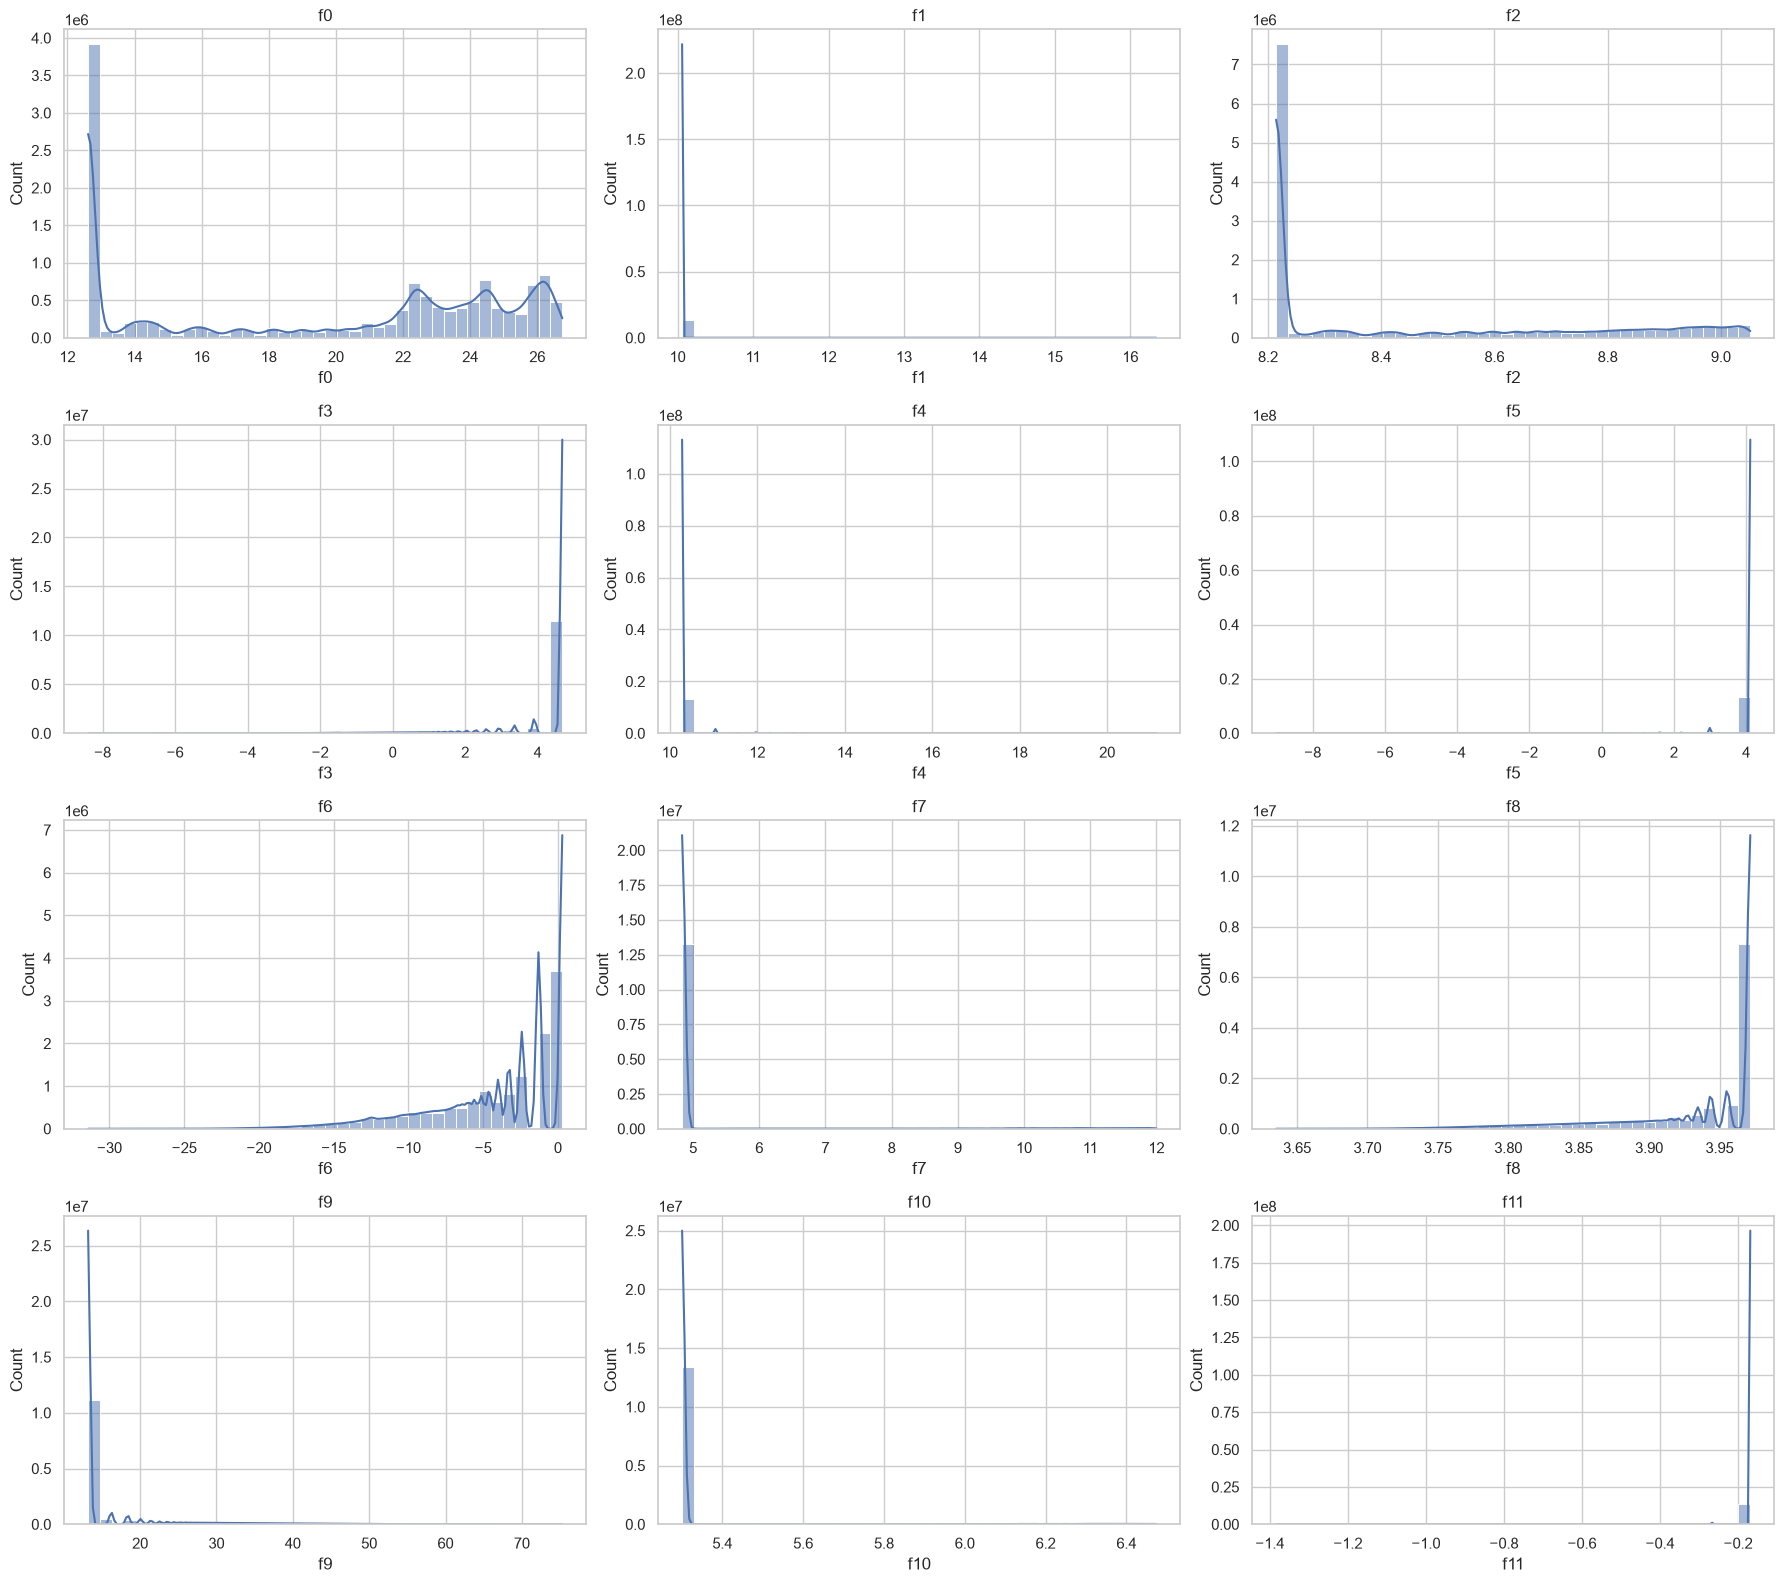

In [49]:
features = [f"f{i}" for i in range(12)]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for ax, feature in zip(axes, features):

    sns.histplot(
        df[feature],
        bins=40,
        kde=True,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()
plt.show()

## 7.2 Distribution Summary

Summarize the numerical features using descriptive statistics, skewness, kurtosis, and unique value counts. These metrics provide an overview of central tendency, variability, distribution shape, and feature diversity, helping assess data quality before causal inference and uplift modeling.

In [50]:
distribution_summary = df[features].describe().T

distribution_summary["Skewness"] = df[features].skew()
distribution_summary["Kurtosis"] = df[features].kurt()
distribution_summary["Unique"] = df[features].nunique()

display(distribution_summary.round(3))

,count,mean,std,min,25%,50%,75%,max,Skewness,Kurtosis,Unique
f0,13979592.00,19.62,5.38,12.62,12.62,21.92,24.44,26.75,-0.25,-1.63,2181959
f1,13979592.00,10.07,0.10,10.06,10.06,10.06,10.06,16.34,14.00,267.55,60
f2,13979592.00,8.45,0.30,8.21,8.21,8.21,8.72,9.05,0.81,-1.01,2051900
f3,13979592.00,4.18,1.34,-8.40,4.68,4.68,4.68,4.68,-3.19,10.51,552
f4,13979592.00,10.34,0.34,10.28,10.28,10.28,10.28,21.12,8.88,104.14,260
f5,13979592.00,4.03,0.43,-9.01,4.12,4.12,4.12,4.12,-7.09,68.82,132
f6,13979592.00,-4.16,4.58,-31.43,-6.70,-2.41,0.29,0.29,-1.14,0.77,1645
f7,13979592.00,5.10,1.21,4.83,4.83,4.83,4.83,12.00,4.53,19.22,622143
f8,13979592.00,3.93,0.06,3.63,3.91,3.97,3.97,3.97,-1.61,1.85,3743
f9,13979592.00,16.03,7.02,13.19,13.19,13.19,13.19,75.30,2.82,7.73,1594


## Findings

The numerical features exhibit diverse distribution patterns.

Several features (e.g., **f0**, **f2**, and **f6**) show relatively continuous distributions with a large number of unique values, indicating that they contain rich numerical information.

Conversely, features such as **f1**, **f3**, **f4**, **f5**, and **f11** are highly concentrated around a small number of values, as evidenced by their extremely high skewness and kurtosis. These variables appear to contain dominant values with relatively few observations in the tails.

Notably:

- **f1** (Skewness = 14.00, Kurtosis = 267.55)
- **f4** (Skewness = 8.88, Kurtosis = 104.14)
- **f5** (Skewness = -7.09, Kurtosis = 68.82)
- **f11** (Skewness = -14.81, Kurtosis = 294.53)

display highly non-normal distributions.

Meanwhile, features such as **f0** and **f2** exhibit relatively symmetric distributions with low skewness and negative kurtosis, suggesting broader value dispersion.

## Implication

The dataset contains a mixture of continuous and highly concentrated numerical variables, which is common in behavioural datasets.

Although several features are strongly skewed, no transformation is applied because the primary uplift models are tree-based algorithms, which are generally robust to skewed feature distributions.

## Decision

All predictor variables will be retained without transformation during the exploratory analysis stage.

## 7.3 Feature Correlation

The correlation matrix is used to evaluate linear relationships between predictor variables and identify potential multicollinearity.

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11
f0,1.00,-0.09,-0.51,0.28,-0.09,0.05,-0.27,-0.00,0.40,-0.29,-0.09,0.08
f1,-0.09,1.00,-0.01,-0.33,0.15,-0.57,-0.19,0.15,-0.14,0.17,0.07,-0.15
f2,-0.51,-0.01,1.00,0.01,0.02,-0.02,0.18,0.04,-0.37,-0.05,0.09,0.03
f3,0.28,-0.33,0.01,1.00,-0.20,0.33,0.55,-0.20,0.28,-0.30,-0.14,0.17
f4,-0.09,0.15,0.02,-0.20,1.00,-0.20,-0.16,0.11,-0.41,0.36,0.66,-0.68
f5,0.05,-0.57,-0.02,0.33,-0.20,1.00,0.36,-0.75,0.20,-0.16,-0.13,0.12
f6,-0.27,-0.19,0.18,0.55,-0.16,0.36,1.00,-0.32,0.12,-0.11,-0.12,0.09
f7,-0.00,0.15,0.04,-0.20,0.11,-0.75,-0.32,1.00,-0.14,0.09,0.10,-0.05
f8,0.40,-0.14,-0.37,0.28,-0.41,0.20,0.12,-0.14,1.00,-0.75,-0.40,0.25
f9,-0.29,0.17,-0.05,-0.30,0.36,-0.16,-0.11,0.09,-0.75,1.00,0.27,-0.36


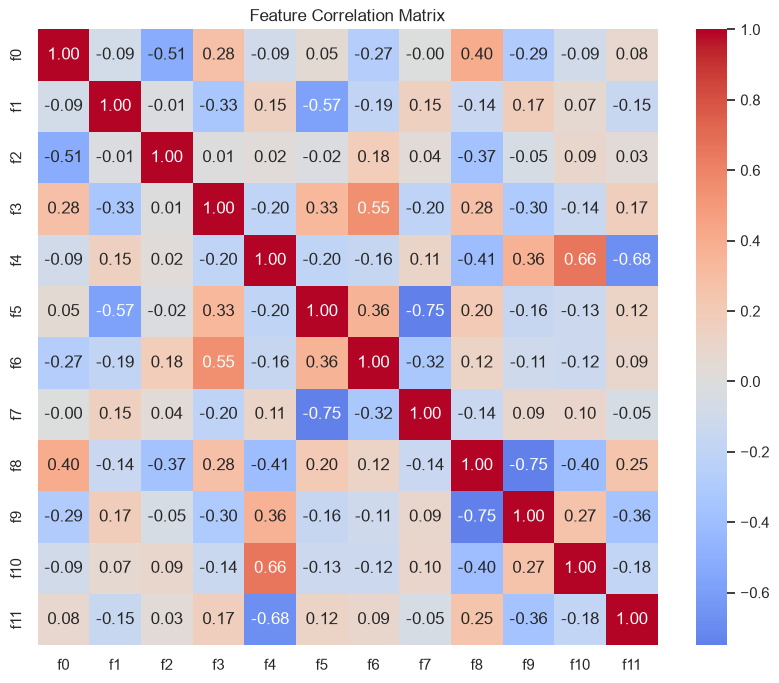

In [51]:
corr = df[features].corr()

display(corr)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [52]:
corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .sort_values(key=lambda x: x.abs(), ascending=False)
        .rename("Correlation")
        .to_frame()
)

display(corr_pairs.head(20))

Correlation
f8  f9         -0.75
f9  f8         -0.75
f7  f5         -0.75
f5  f7         -0.75
f11 f4         -0.68
f4  f11        -0.68
    f10         0.66
f10 f4          0.66
f1  f5         -0.57
f5  f1         -0.57
f6  f3          0.55
f3  f6          0.55
f0  f2         -0.51
f2  f0         -0.51
f4  f8         -0.41
f8  f4         -0.41
f0  f8          0.40
f8  f0          0.40
    f10        -0.40
f10 f8         -0.40



### Findings

Overall, most feature pairs exhibit weak to moderate linear correlations.

The strongest correlations observed are:

| Feature Pair | Correlation |
|--------------|------------:|
| f5 – f7 | -0.75 |
| f8 – f9 | -0.75 |
| f4 – f11 | -0.68 |
| f4 – f10 | 0.66 |
| f3 – f6 | 0.55 |
| f0 – f2 | -0.51 |

Although several feature pairs show moderate correlations, no feature pair exceeds an absolute correlation coefficient of 0.90.

### Implication

The observed correlations suggest that some variables may capture related behavioural patterns. However, the correlations are not sufficiently high to indicate severe multicollinearity.

Since the primary uplift models in this project are tree-based meta-learners, moderate correlations between predictors are unlikely to adversely affect model performance.

### Decision

No features will be removed based on pairwise correlation. All predictor variables will be retained for subsequent modeling.

## 8. Summary of Exploratory Data Analysis

The exploratory analysis revealed the following characteristics of the dataset:

| Observation | Evidence | Modeling Implication |
|-------------|----------|----------------------|
| No missing values | Missing value assessment | No imputation required |
| No invalid values | Data quality assessment | Minimal data cleaning required |
| Duplicate observations exist | Approximately 1.26 million duplicate rows | Retained as they likely represent repeated customer records |
| Outliers present | Several numerical features contain extreme values | Retained because they likely represent genuine customer behaviour |
| Numerical features exhibit skewed distributions | High skewness and kurtosis in several variables | Distributional characteristics should be considered when selecting and interpreting causal models |
| Moderate feature correlations | Maximum absolute correlation = 0.75 | No evidence of severe multicollinearity |
| Treatment assignment is imbalanced | 85% Treatment vs 15% Control | Models robust to treatment imbalance are preferred |
| Outcome is highly imbalanced | Conversion rate = 0.29% | Class imbalance should be considered during model evaluation |
| Treatment shows higher conversion | Treatment: 0.31% vs Control: 0.19% | Positive treatment effect is observed, supporting uplift modeling |